In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
import sqlite3
from scipy.stats import stats
import warnings
warnings.filterwarnings('ignore')

In [3]:
#creating a connection with db 
conn=sqlite3.connect('inventory.db')

#loading the dataset
df=pd.read_sql_query("select * from vendor_sales_summary",conn)
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,42883.0,1561426.17,270159.97,78791.44,68601.68,-2249825.43,-144.087852,0.295582,0.409689
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,44781.0,1355030.15,223294.82,82279.33,144929.24,-2449011.07,-180.734803,0.272992,0.356208
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,55523.0,1395710.27,189721.15,102016.92,123780.22,-2022593.41,-144.914991,0.296270,0.408305
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,87151.0,1950609.49,177016.94,160133.77,257032.07,-1310588.45,-67.188664,0.432121,0.598127
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,43491.0,1370891.09,216638.67,79909.05,257032.07,-1652314.92,-120.528533,0.314903,0.453456
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10687,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
10688,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,128.0,62.72,0.98,6.72,50293.62,60.38,96.269133,21.333333,26.803419
10689,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,0.0,0.00,0.00,0.00,14069.87,-1.48,-inf,0.000000,0.000000
10690,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,25.0,49.75,27.86,5.25,257032.07,48.28,97.045226,25.000000,33.843537


In [4]:
df.describe().T #t FOR TRANSPOSE AS WE WERE NOT ABLE TO SEE ALL THE COLUMNS CORRECTLY THEREFORE IT CONVERTED THE COLUMNS TO ROWS AND ROWS TO CLUMN 

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,1.024393e+03,3847.407065,0.00,4.000000,63.000000,573.000000,1.278040e+05
TotalSalesDollars,10692.0,1.375681e+04,54172.513086,0.00,74.985000,1299.415000,9027.177500,1.950609e+06
TotalSalesPrice,10692.0,6.595470e+03,16850.732515,0.00,19.980000,655.250000,5132.120000,2.701600e+05


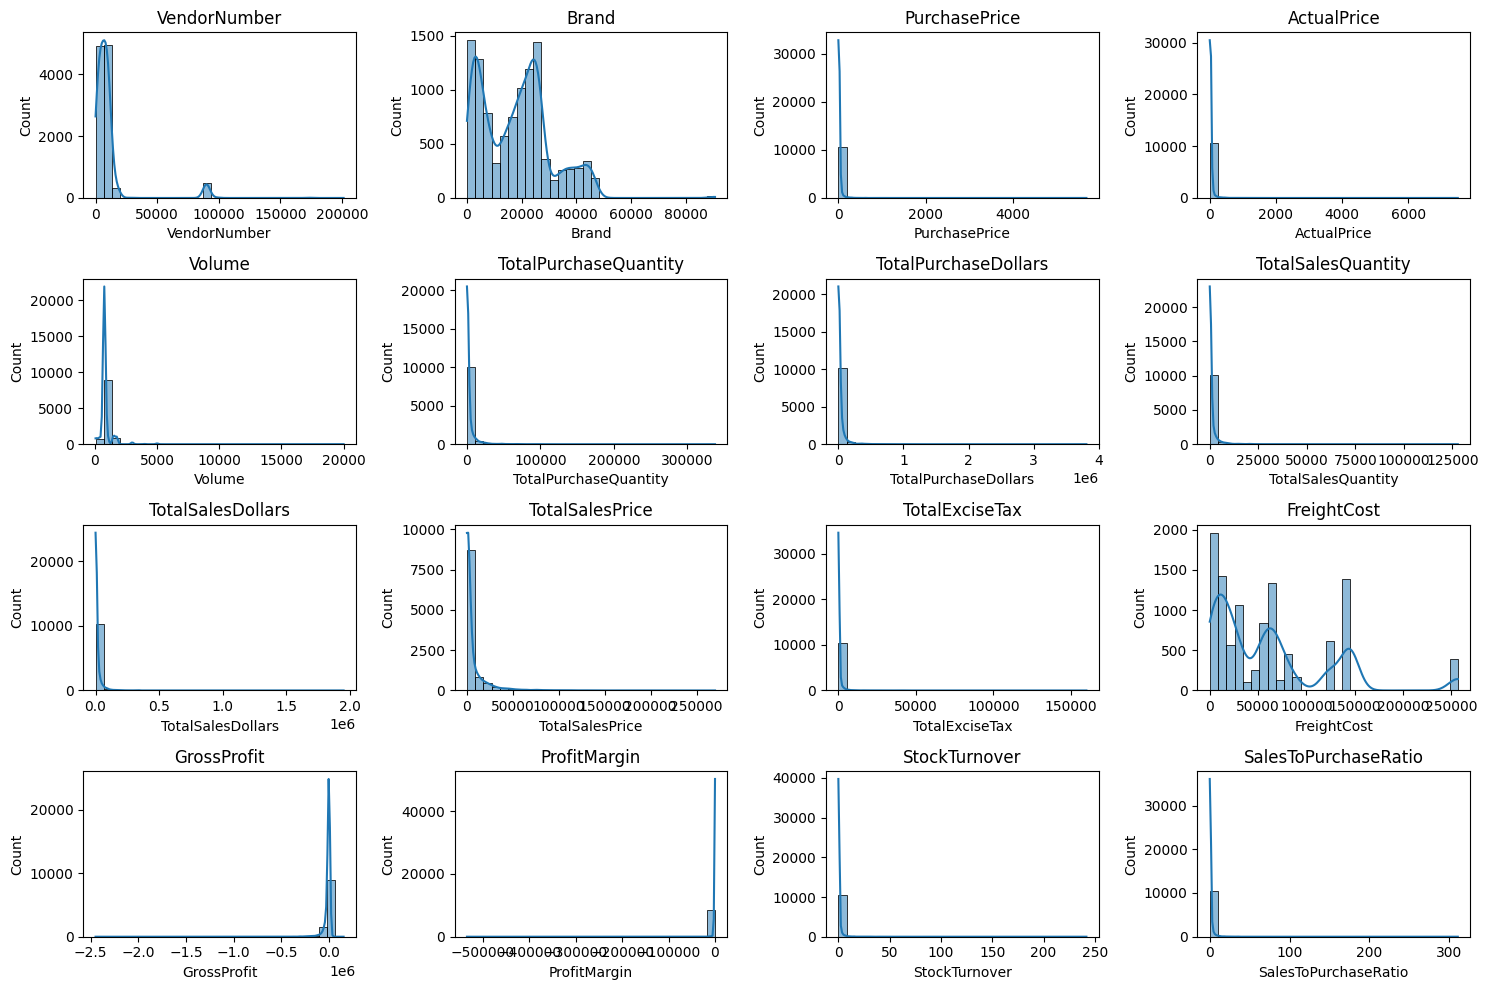

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution Plots for Numerical Columns
# This selects only columns with numbers (int, float)
numerical_cols = df.select_dtypes(include=np.number).columns

# Create a large figure to hold all subplots
plt.figure(figsize=(15, 10))

# Loop through each numerical column to create a chart
#enumerate() is used to loop over something and get BOTH:index and the value
for i, col in enumerate(numerical_cols):
    # Adjust grid layout as needed (4 rows, 4 columns)
    plt.subplot(4, 4, i+1) 
    
    # Create the histogram with a Kernel Density Estimate (KDE) curve
    sns.histplot(df[col], kde=True, bins=30)
    
    # Label the chart with the column name
    plt.title(col)

# Automatically adjust spacing between charts
plt.tight_layout()

# Display the final visualization
plt.show()

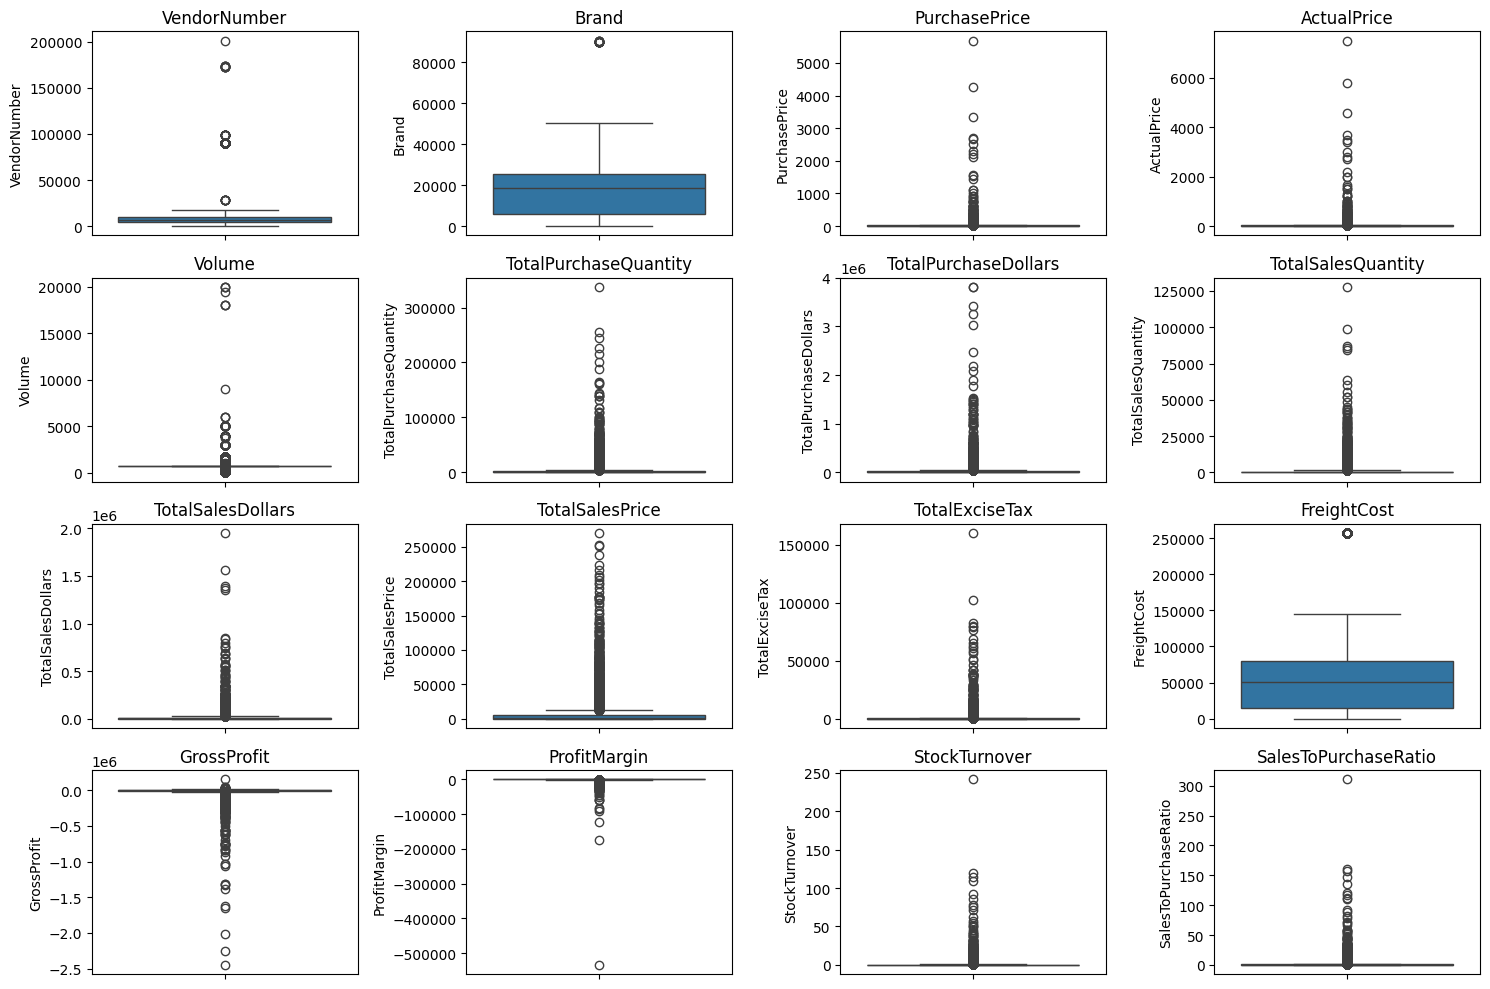

In [6]:
#outlier detection
plt.figure(figsize=(15,10))
for i ,col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

Summary Statistics Insights:
Negative & Zero Values:
Gross Profit: Minimum value is -52,002.78, indicating losses. Some products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price.

Profit Margin: Has a minimum of -inf (negative infinity), which suggests cases where revenue is zero or even lower than costs.

Total Sales Quantity & Sales Dollars: Minimum values are 0, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock.

Outliers Indicated by High Standard Deviations:
Purchase & Actual Prices: The max values (5,681.81 & 7,499.99) are significantly higher than the mean (24.39 & 35.64), indicating potential premium products.

Freight Cost: Huge variation, from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.

Stock Turnover: Ranges from 0 to 274.5, implying some products sell extremely fast while others remain in stock indefinitely. A value more than 1 indicates that sold quantity for that product is higher than purchased quantity due to either sales being fulfilled from older stock.

In [7]:
#we cant remove all the outliers we will just filter out thw data by removing the inconcsistencies 
df=pd.read_sql_query("""select *
from vendor_sales_summary 
where GrossProfit>0 and ProfitMargin>0 and TotalSalesQuantity>0 """,conn)

In [8]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,5299,Southern Comfort,15.26,21.99,1750.0,15196,231890.96,11767.0,270826.33,110368.31,21620.75,68601.68,38935.37,14.376508,0.774349,1.167904
1,12546,JIM BEAM BRANDS COMPANY,1476,Jim Beam Traveler,16.05,21.99,1750.0,11569,185682.45,14831.0,337503.69,90149.32,27248.90,123880.97,151821.24,44.983579,1.281960,1.817639
2,1128,BROWN-FORMAN CORP,5297,Southern Comfort,10.76,13.99,750.0,8616,92708.16,6480.0,94079.20,52662.01,5104.49,68601.68,1371.04,1.457325,0.752089,1.014789
3,4425,MARTIGNETTI COMPANIES,36380,Sebastiani Znfdl Sonoma Cnty,6.49,9.99,750.0,12309,79885.41,9233.0,92237.67,26323.65,1034.41,144929.24,12352.26,13.391774,0.750102,1.154625
4,3252,E & J GALLO WINERY,34134,Turning Leaf RSV Chard Cal,5.84,9.99,1500.0,12276,71691.84,7666.0,73917.34,31023.97,1718.15,61966.91,2225.50,3.010796,0.624471,1.031043
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1846,3960,DIAGEO NORTH AMERICA INC,2626,Crown Royal Apple,1.42,1.99,50.0,2,2.84,12.0,23.88,1.99,0.63,257032.07,21.04,88.107203,6.000000,8.408451
1847,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
1848,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,128.0,62.72,0.98,6.72,50293.62,60.38,96.269133,21.333333,26.803419
1849,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,25.0,49.75,27.86,5.25,257032.07,48.28,97.045226,25.000000,33.843537


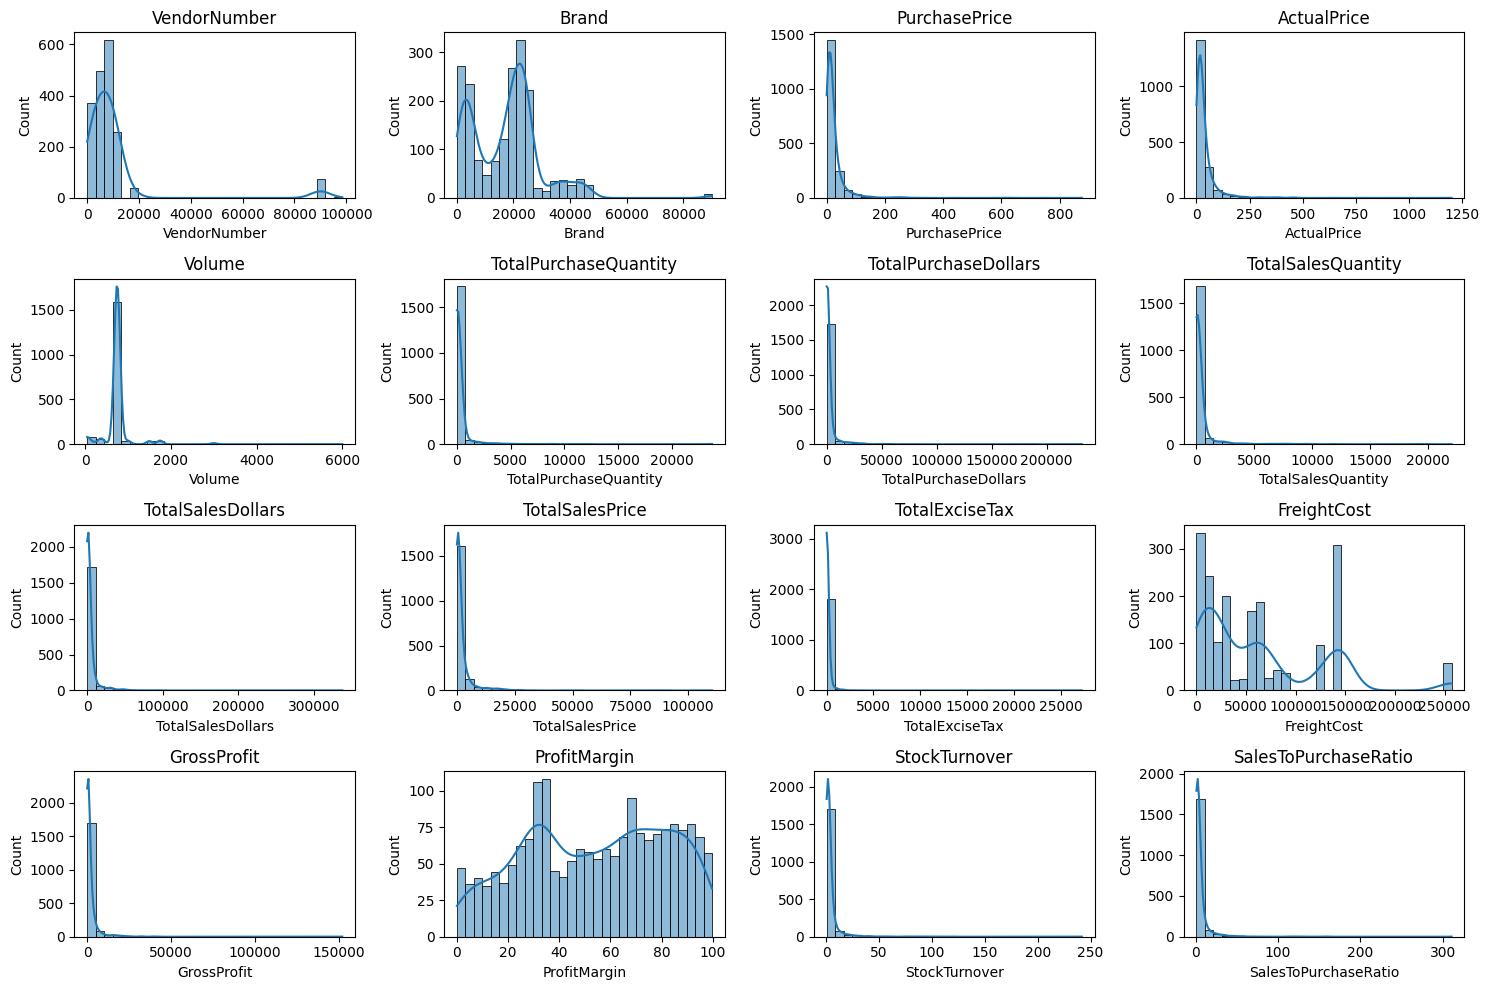

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution Plots for Numerical Columns
# This selects only columns with numbers (int, float)
numerical_cols = df.select_dtypes(include=np.number).columns

# Create a large figure to hold all subplots
plt.figure(figsize=(15, 10))

# Loop through each numerical column to create a chart
#enumerate() is used to loop over something and get BOTH:index and the value
for i, col in enumerate(numerical_cols):
    # Adjust grid layout as needed (4 rows, 4 columns)
    plt.subplot(4, 4, i+1) 
    
    # Create the histogram with a Kernel Density Estimate (KDE) curve
    sns.histplot(df[col], kde=True, bins=30)
    
    # Label the chart with the column name
    plt.title(col)

# Automatically adjust spacing between charts
plt.tight_layout()

# Display the final visualization
plt.show()

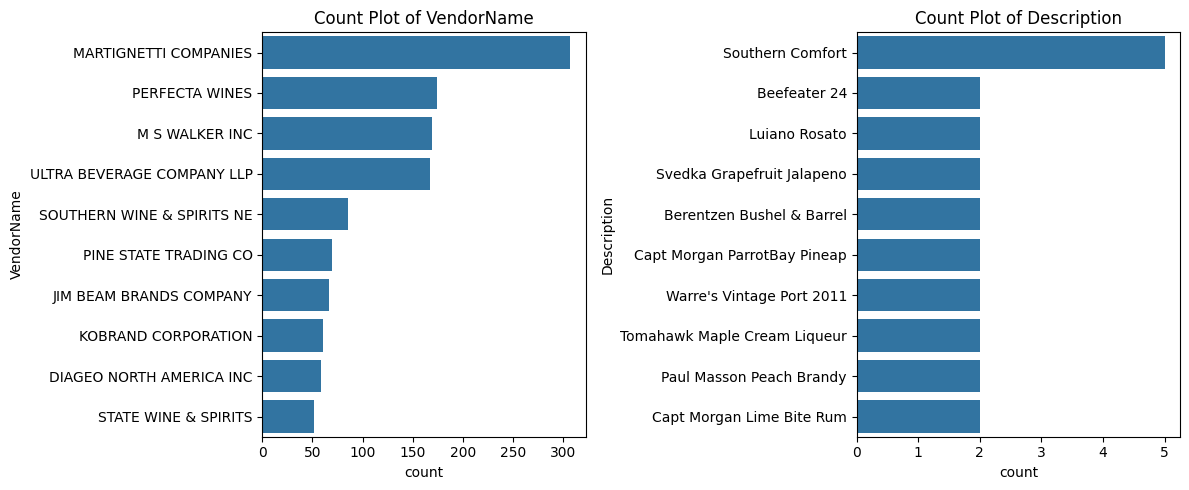

In [10]:
#count plot for categorical data 
categorical_data=["VendorName","Description"]
plt.figure(figsize=(12,5))
for i ,col in enumerate(categorical_data):
    plt.subplot(1,2,i+1)
    sns.countplot(y=df[col],order=df[col].value_counts().index[:10])
    plt.title(f"Count Plot of {col}")

plt.tight_layout()
plt.show()
    

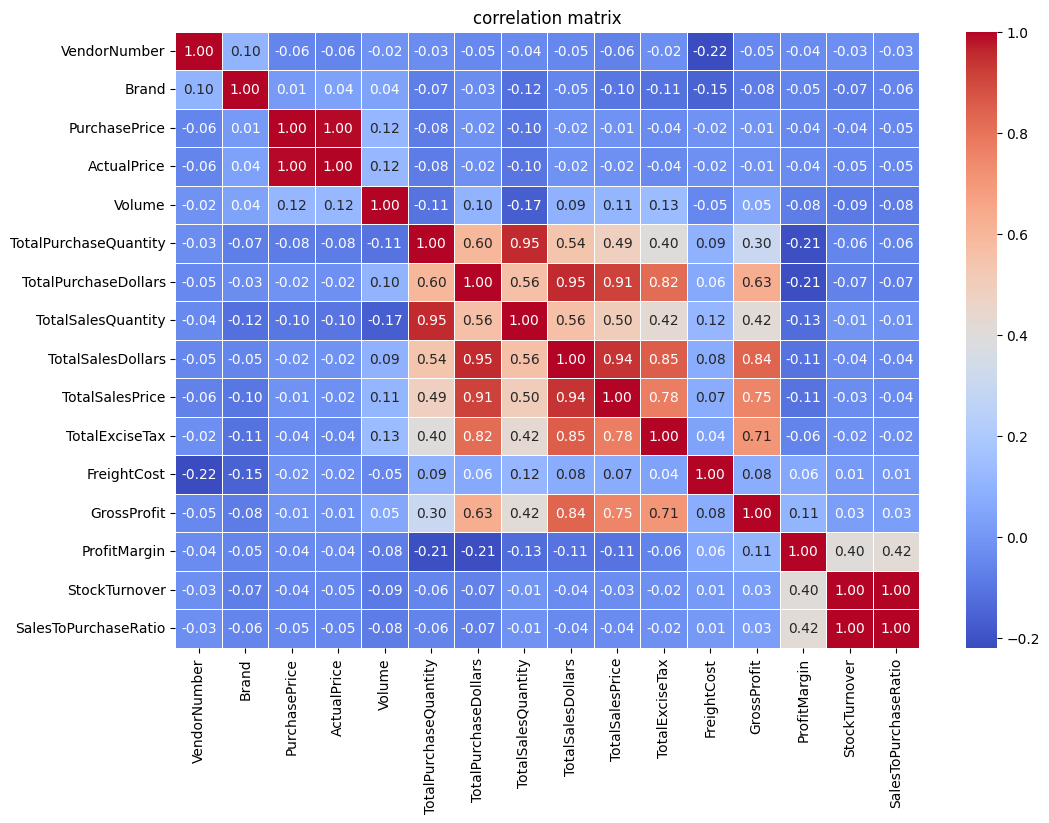

In [11]:
#correlation matrix
plt.figure(figsize=(12,8))
correlation_matrix=df[numerical_cols].corr()
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',linewidth=0.5,fmt='.2f')
plt.title("correlation matrix")
plt.show()

Correlation Insights

PurchasePrice vs. Sales/Profit: PurchasePrice has weak correlations with TotalSalesDollars (-0.012) and GrossProfit (-0.016), suggesting that price variations do not significantly impact sales revenue or profit.

Inventory Efficiency: Strong correlation between total purchase quantity and total sales quantity (0.999), confirming efficient inventory turnover.

Pricing Pressure: Negative correlation between profit margin and total sales price (-0.179) suggests that as sales price increases, margins decrease, possibly due to competitive pricing pressures.

Turnover vs. Profit: StockTurnover has weak negative correlations with both GrossProfit (-0.038) and ProfitMargin (-0.055), indicating that faster turnover does not necessarily result in higher profitability.

## DATA ANALYSIS

 IDENTIFY THOSE BRANDS WHO NEED PROMOTIONAL AND PRICING ADJUSTMENT  WHOSE SALES PERFROMANCE IS LW BUT PROFIT MARGIN IS HIGH

In [12]:
brand_performance=df.groupby('Description').agg({'TotalSalesDollars':'sum',
                               'ProfitMargin':'mean'}).reset_index()

In [13]:
low_sales_threshold=brand_performance['TotalSalesDollars'].quantile(0.15)

In [14]:
low_sales_threshold

223.93

In [15]:
high_sales_margin=brand_performance['ProfitMargin'].quantile(0.85)

In [16]:
high_sales_margin

86.3358477198927

In [17]:
#fikltering the brands with low sales but high profit margin 
target_brands=brand_performance[(brand_performance['TotalSalesDollars']<=low_sales_threshold) 
    &(brand_performance['ProfitMargin']>=high_sales_margin)]
print("brands with high sales but low profit margin:")
display(target_brands.sort_values('TotalSalesDollars'))


brands with high sales but low profit margin:


,Description,TotalSalesDollars,ProfitMargin
588,Crown Royal Apple,23.88,88.107203
1700,Tracia Syrah,44.94,88.495772
1650,The Club Strawbry Margarita,49.75,97.045226
1649,The Club Mudslide,61.69,88.247690
668,Dr McGillicuddy's Apple Pie,62.72,96.269133
1453,Sauza Sparkling Margarita,62.91,91.448100
1342,Promesses de France CdRhone,71.91,92.337644
1671,Three Olives Grape Vodka,85.14,99.166079
82,Aresti Pnt Nr Curico Vly,89.82,96.348252
1395,Riunite Sweet White,95.84,95.722037


In [18]:
brand_performance=brand_performance[brand_performance['TotalSalesDollars']<10000]

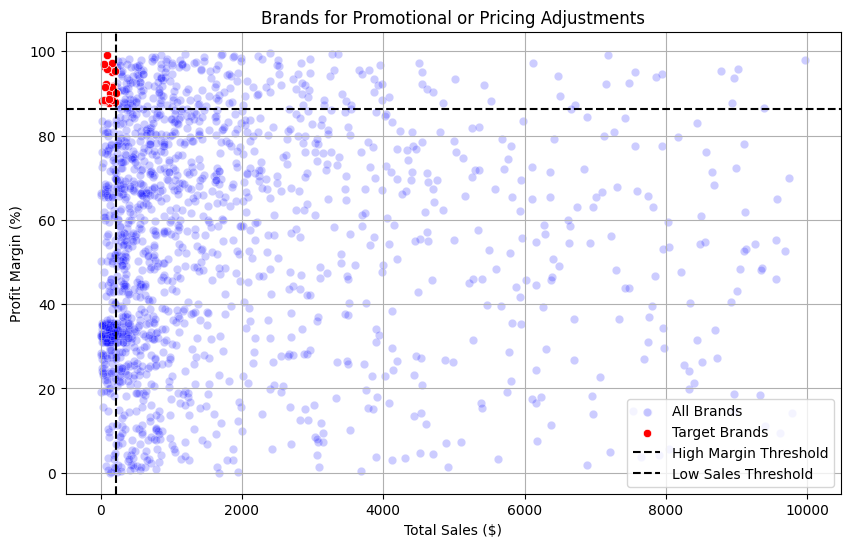

In [19]:
plt.figure(figsize=(10, 6))

# Plot all brands in blue
sns.scatterplot(data=brand_performance, x='TotalSalesDollars', y='ProfitMargin', 
                color="blue", label="All Brands", alpha=0.2)

# Plot only the target brands in red
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin', 
                color="red", label="Target Brands")

# Add the dotted threshold lines
plt.axhline(high_sales_margin, linestyle='--', color='black', label="High Margin Threshold")
plt.axvline(low_sales_threshold, linestyle='--', color='black', label="Low Sales Threshold")

# Labels and Titles
plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

which vendor and brand demonstrates the high sales performance?

In [20]:
def format_dollars(value):
    if value>=1_000_000:
        return f"{value/1_000_000:.2f}M"
    elif value>=1_000:
        return f"{value/1_000:.2f}K"
    else:
        return str(value)

In [21]:
top_vendors=df.groupby('VendorName')['TotalSalesDollars'].sum().nlargest(10)
top_brands=df.groupby('Description')['TotalSalesDollars'].sum().nlargest(10)


In [22]:
top_vendors

VendorName
MARTIGNETTI COMPANIES         1509195.39
ULTRA BEVERAGE COMPANY LLP     931198.90
JIM BEAM BRANDS COMPANY        664610.00
BROWN-FORMAN CORP              599248.00
M S WALKER INC                 435808.11
PERFECTA WINES                 401944.06
DIAGEO NORTH AMERICA INC       267420.79
BACARDI USA INC                233430.54
STATE WINE & SPIRITS           218933.92
E & J GALLO WINERY             197561.30
Name: TotalSalesDollars, dtype: float64

In [23]:
top_brands

Description
Southern Comfort                474653.92
Jim Beam Traveler               337503.69
Sebastiani Znfdl Sonoma Cnty     92237.67
Peter Lehmann Shiraz             81172.93
Turning Leaf RSV Chard Cal       73917.34
Frescobaldi Sangiovese Remo      67208.95
Acumen Moutainside Red Napa      62400.03
Hennessy VSOP Cognac + 50mL      58112.50
Schug Pnt Nr Carneros            56140.21
Forefront Pine Ridge Znfdl       53871.07
Name: TotalSalesDollars, dtype: float64

In [24]:
top_brands.apply(lambda x:format_dollars(x))

Description
Southern Comfort                474.65K
Jim Beam Traveler               337.50K
Sebastiani Znfdl Sonoma Cnty     92.24K
Peter Lehmann Shiraz             81.17K
Turning Leaf RSV Chard Cal       73.92K
Frescobaldi Sangiovese Remo      67.21K
Acumen Moutainside Red Napa      62.40K
Hennessy VSOP Cognac + 50mL      58.11K
Schug Pnt Nr Carneros            56.14K
Forefront Pine Ridge Znfdl       53.87K
Name: TotalSalesDollars, dtype: object

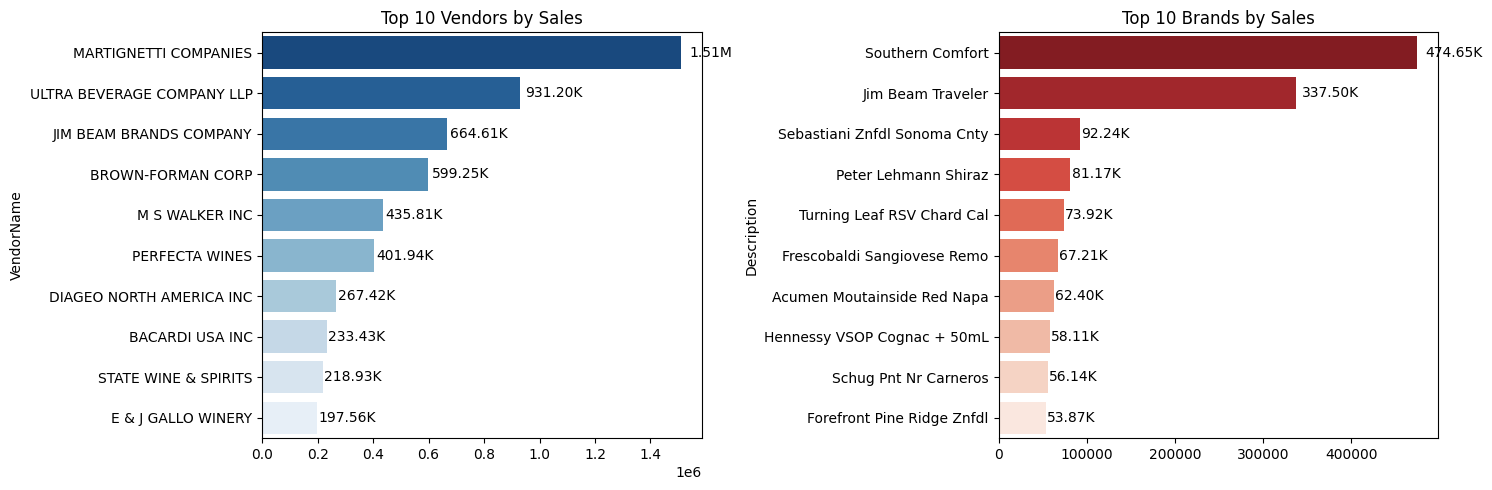

In [25]:
plt.figure(figsize=(15, 5))

# Plot for Top Vendors
plt.subplot(1, 2, 1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

# Plot for Top Brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(y=top_brands.index.astype(str), x=top_brands.values, palette="Reds_r")
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

which vendor contribute to the most to the total purchase dollars

In [33]:
vendor_performance=df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'TotalSalesDollars':sum,
    'GrossProfit':'sum'}).reset_index()


In [34]:
vendor_performance['PurchaseContribution%']=vendor_performance['TotalPurchaseDollars']/vendor_performance['TotalPurchaseDollars'].sum
#eachv and every vendor purchase is divided buy the total purchase 

In [35]:
vendor_performance

,VendorName,TotalPurchaseDollars,TotalSalesDollars,GrossProfit,PurchaseContribution%
0,ALISA CARR BEVERAGES,16146.99,33141.69,16994.70,0.003762
1,ATLANTIC IMPORTING COMPANY,3230.68,8118.52,4887.84,0.000753
2,BACARDI USA INC,87278.23,233430.54,146152.31,0.020337
3,BANFI PRODUCTS CORP,9190.27,14399.88,5209.61,0.002141
4,BLACK PRINCE DISTILLERY INC,4448.78,9354.65,4905.87,0.001037
...,...,...,...,...,...
81,VRANKEN AMERICA,6845.27,17060.21,10214.94,0.001595
82,WEIN BAUER INC,95.04,137.88,42.84,0.000022
83,WESTERN SPIRITS BEVERAGE CO,17191.84,36752.94,19561.10,0.004006
84,WILLIAM GRANT & SONS INC,18000.00,40514.11,22514.11,0.004194


In [42]:
vendor_performance=round(vendor_performance.sort_values('PurchaseContribution%' , ascending=False),2)

In [43]:
top_vendors=vendor_performance.head(10)
top_vendors['TotalSalesDollars']=top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars']=top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit']=top_vendors['GrossProfit'].apply(format_dollars)
top_vendors

,VendorName,TotalPurchaseDollars,TotalSalesDollars,GrossProfit,PurchaseContribution%
37,MARTIGNETTI COMPANIES,872.16K,1.51M,637.03K,0.20
76,ULTRA BEVERAGE COMPANY LLP,512.37K,931.20K,418.83K,0.12
5,BROWN-FORMAN CORP,465.27K,599.25K,133.98K,0.11
27,JIM BEAM BRANDS COMPANY,382.02K,664.61K,282.59K,0.09
47,PERFECTA WINES,235.45K,401.94K,166.49K,0.05
34,M S WALKER INC,185.50K,435.81K,250.31K,0.04
18,E & J GALLO WINERY,150.76K,197.56K,46.80K,0.04
14,DIAGEO NORTH AMERICA INC,132.69K,267.42K,134.73K,0.03
66,STATE WINE & SPIRITS,101.90K,218.93K,117.03K,0.02
41,MOET HENNESSY USA INC,94.97K,156.05K,61.08K,0.02


In [44]:
#1. Identify top vendors (Pareto Principle – 80/20 rule)

#Most business problems follow:

#👉 80% of results come from 20% of vendors

#Cumulative helps you answer:

#Which vendors contribute to 80% of total purchases?
#Who are your most important vendors?

top_vendors['Cumulative_Contribution%']=top_vendors['PurchaseContribution%'].cumsum()


In [45]:
top_vendors

,VendorName,TotalPurchaseDollars,TotalSalesDollars,GrossProfit,PurchaseContribution%,Cumulative_Contribution%
37,MARTIGNETTI COMPANIES,872.16K,1.51M,637.03K,0.20,0.20
76,ULTRA BEVERAGE COMPANY LLP,512.37K,931.20K,418.83K,0.12,0.32
5,BROWN-FORMAN CORP,465.27K,599.25K,133.98K,0.11,0.43
27,JIM BEAM BRANDS COMPANY,382.02K,664.61K,282.59K,0.09,0.52
47,PERFECTA WINES,235.45K,401.94K,166.49K,0.05,0.57
34,M S WALKER INC,185.50K,435.81K,250.31K,0.04,0.61
18,E & J GALLO WINERY,150.76K,197.56K,46.80K,0.04,0.65
14,DIAGEO NORTH AMERICA INC,132.69K,267.42K,134.73K,0.03,0.68
66,STATE WINE & SPIRITS,101.90K,218.93K,117.03K,0.02,0.70
41,MOET HENNESSY USA INC,94.97K,156.05K,61.08K,0.02,0.72


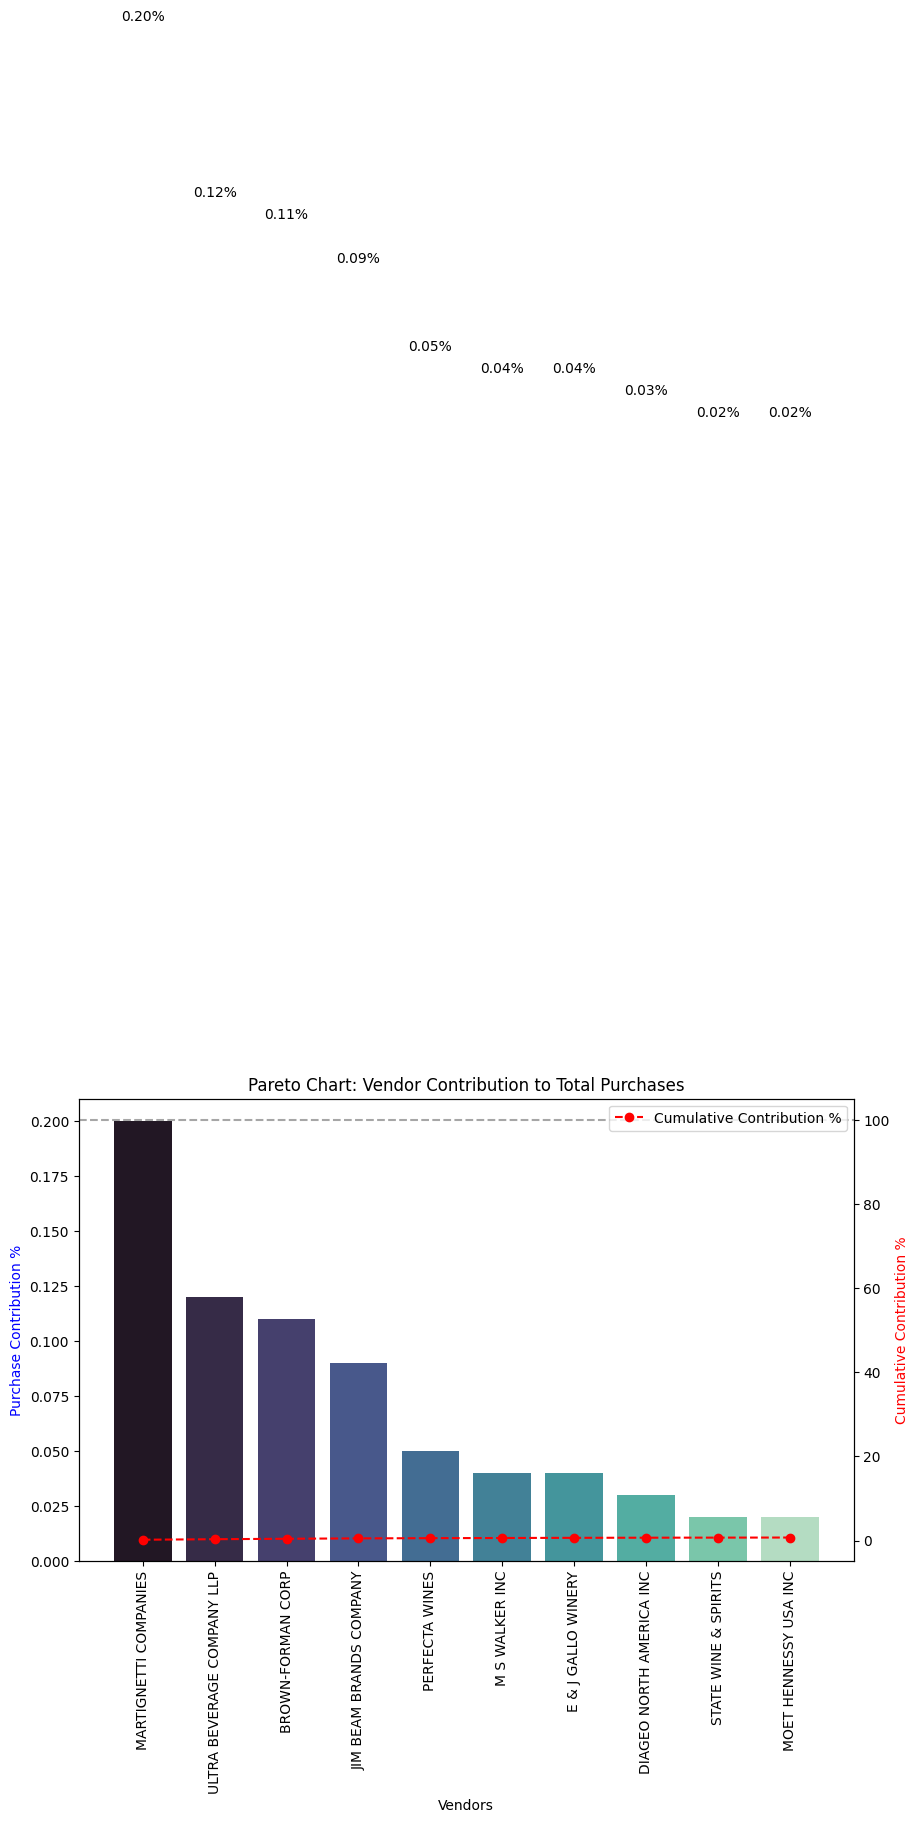

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Purchase Contribution %
sns.barplot(
    x=top_vendors['VendorName'],
    y=top_vendors['PurchaseContribution%'],
    palette="mako",
    ax=ax1
)

# Add labels on each bar
for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i,value + 0.5,   # place ABOVE bar instead of inside
        f'{value:.2f}%',
             ha='center', fontsize=10, color='black')

# Create second axis for cumulative contribution
ax2 = ax1.twinx()

# Line plot for cumulative contribution %
ax2.plot(
    top_vendors['VendorName'],
    top_vendors['Cumulative_Contribution%'],
    color='red',
    marker='o',
    linestyle='dashed',
    label='Cumulative Contribution %'
)

# Formatting
ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

# Reference line at 100%
ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)

# Legend
ax2.legend(loc='upper right')

# Show plot
plt.show()

How much total procurement is dependent on the top vendors

In [56]:
#Procurement = Buying things for a company in a structured and strategic way
print(f"Total Purchase Contribution of the top 10 vendors is {round(top_vendors['PurchaseContribution%'].sum(),2)}%")

Total Purchase Contribution of the top 10 vendors is 0.72%


In [61]:
#Procurement = Buying things for a company in a structured and strategic way
print(f"Total Purchase Contribution of the top 10 vendors is {top_vendors['PurchaseContribution%'].sum() * 100:.2f}%")

Total Purchase Contribution of the top 10 vendors is 72.00%


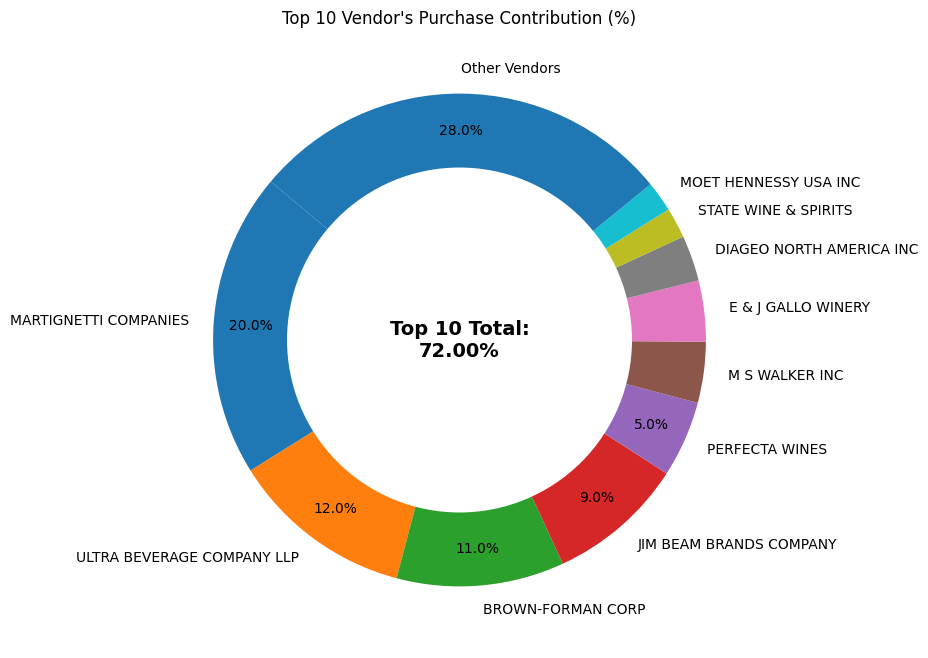

In [66]:
# 1. Prepare Data
vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['PurchaseContribution%'].values)

# 2. Convert decimal (0–1) → percentage (0–100)
if max(purchase_contributions) <= 1:
    purchase_contributions = [x * 100 for x in purchase_contributions]

# 3. Calculate totals
total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# 4. Safety check (avoid negative values)
if remaining_contribution < 0:
    remaining_contribution = 0

# 5. Add "Other Vendors"
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# 6. Function to avoid label clutter
def autopct_format(pct):
    return f'{pct:.1f}%' if pct > 5 else ''

# 7. Create Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    purchase_contributions,
    labels=vendors,
    autopct=autopct_format,
    startangle=140,
    pctdistance=0.85
)

# 8. Create donut hole
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# 9. Add center text (correct %)
plt.text(
    0, 0,
    f"Top 10 Total:\n{total_contribution:.2f}%",
    fontsize=14,
    fontweight='bold',
    ha='center',
    va='center'
)

# 10. Title
plt.title("Top 10 Vendor's Purchase Contribution (%)")

# 11. Show plot
plt.show()


Does purchasing in bulk reduces the unit price and what is the optimal volume for cost saving

In [68]:
df['UnitPurchasePrice']=df['TotalPurchaseDollars']/df['TotalPurchaseQuantity']
#price of the single quantity

In [71]:
df['OrderSize']=pd.qcut(df['TotalPurchaseQuantity'],q=3,labels=['small','medium','large'])
#pd.qcut perfroms the quantile based binning that means here q is given as 3 that means it will group the data from TotalPurchaseQuantitty in 3 groups and assign the velkues in the OrderSize as small ,medium and large 


In [72]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()
#from this we can see that if vendors puchase more product in bulk the pricing is less and in small quantity the pricing is more 

,UnitPurchasePrice
OrderSize,
small,37.909307
medium,23.819496
large,12.242545


which vendors have low inventory turnover and excess stocks and slow moving products?

In [74]:
#low inventory means the comapany is sellings its goods in slow period of time and the goods are sitting in the inventory for the longer period of time 
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover',ascending=True).head(10)
#You are identifying vendors whose products are selling very slowly (low demand or overstocked).

,StockTurnover
VendorName,
THE IMPORTED GRAPE LLC,0.544246
PSP WINES,0.583333
SURVILLE ENTERPRISES CORP,0.650210
FREDERICK WILDMAN & SONS,0.656643
WINE GROUP INC,0.666667
SHAW ROSS INT L IMP LTD,0.666667
STELLAR IMPORTING CO LLC,0.666667
POVERTY LANE ORCHARDS,0.679078
"STOLI GROUP,(USA) LLC",0.695246


how much capital is locked in unsold inventory per vendor and which vendor contribute the most to it ?

In [76]:
#to calculte the unsold quantity we will follow the formula 
#puchasedquantity-soldquantity*unit price
# Step 1: Quantity
df['UnsoldQuantity'] = (df['TotalPurchaseQuantity'] - df['TotalSalesQuantity']).clip(lower=0) #clip(lower=0) any value that is less than 0 make it 0

# Step 2: Value
df['UnsoldValue'] = df['UnsoldQuantity'] * df['PurchasePrice']
print("Total Unsold Value:", format_dollars(df['UnsoldValue'].sum()))

Total Unsold Value: 504.03K


In [80]:
Inventory_value_per_vendor=df.groupby('VendorName')['UnsoldValue'].sum().reset_index()
#sort the vendors with the highest capital lock
Inventory_value_per_vendor=Inventory_value_per_vendor.sort_values(by="UnsoldValue",ascending=False)
Inventory_value_per_vendor['UnsoldValue']=Inventory_value_per_vendor['UnsoldValue'].apply(format_dollars)
Inventory_value_per_vendor.head(10)

,VendorName,UnsoldValue
37,MARTIGNETTI COMPANIES,122.63K
5,BROWN-FORMAN CORP,95.90K
76,ULTRA BEVERAGE COMPANY LLP,50.25K
18,E & J GALLO WINERY,40.65K
22,FREDERICK WILDMAN & SONS,25.04K
47,PERFECTA WINES,23.29K
67,STE MICHELLE WINE ESTATES,17.38K
34,M S WALKER INC,12.55K
27,JIM BEAM BRANDS COMPANY,12.46K
64,SOUTHERN WINE & SPIRITS NE,11.04K


What is 95% confidence interval for profit margin of top performing and low performing vendors 

In [81]:
#95% CI gives a reliable range where the true profit margin is expected to lie
#lets sets the threshold 
top_performing=df['TotalSalesDollars'].quantile(0.75)
low_performing=df['TotalSalesDollars'].quantile(0.25)

In [83]:
top_vendors.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10 entries, 37 to 41
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   VendorName                10 non-null     object 
 1   TotalPurchaseDollars      10 non-null     object 
 2   TotalSalesDollars         10 non-null     object 
 3   GrossProfit               10 non-null     object 
 4   PurchaseContribution%     10 non-null     float64
 5   Cumulative_Contribution%  10 non-null     float64
dtypes: float64(2), object(4)
memory usage: 560.0+ bytes


In [87]:
df.columns

Index(['VendorNumber', 'VendorName', 'Brand', 'Description', 'PurchasePrice',
       'ActualPrice', 'Volume', 'TotalPurchaseQuantity',
       'TotalPurchaseDollars', 'TotalSalesQuantity', 'TotalSalesDollars',
       'TotalSalesPrice', 'TotalExciseTax', 'FreightCost', 'GrossProfit',
       'ProfitMargin', 'StockTurnover', 'SalesToPurchaseRatio',
       'UnitPurchasePrice', 'OrderSize', 'UnsoldQuantity', 'UnsoldValue'],
      dtype='object')

In [88]:
top_vendors=df[df["TotalSalesDollars"]>=top_performing]["ProfitMargin"].dropna()
low_vendors=df[df["TotalSalesDollars"]<=low_performing]["ProfitMargin"].dropna()

In [89]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data)) # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

Top Vendors 95% CI: (47.36, 52.47), Mean: 49.92
Low Vendors 95% CI: (46.06, 50.60), Mean: 48.33


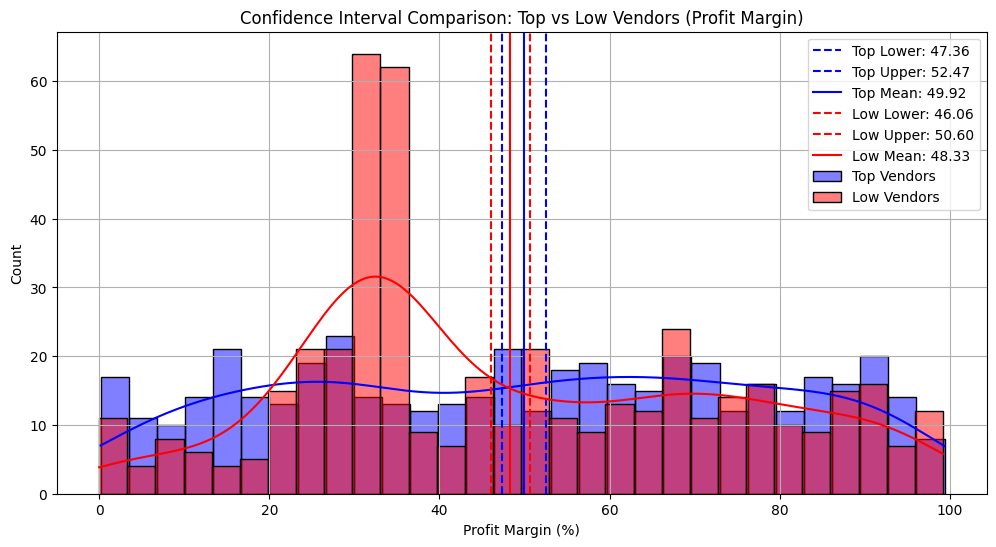

In [91]:
import numpy as np
from scipy import stats
# Calculate Confidence Intervals for both groups
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

# Print the results for a quick check
print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# --- Top Vendors Plot ---
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# --- Low Vendors Plot ---
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.grid()
plt.legend()
plt.show()

What it says: Because the intervals overlap, it suggests that even though there is a difference in average profit, the "best" of the low vendors are actually performing similarly to the "average" of the top vendors.

The Action: You shouldn't necessarily fire the "Low Vendors" immediately. Instead, you should look at the ones in that 30% spike and see why they are trailing behind the others.